In [1]:
import matplotlib.pyplot as plt
import numpy as np
from astropy.io import fits

import yaml
import os.path as op

from specula.mmlib.analyse_data import plot_output_data, compute_radial_profile, get_reference_psf, get_sim_data, get_residual_psd
from specula.mmlib.plot_gain_opt import plot_gain_optimization
from specula.mmlib.utils import reshape_on_mask
from specula.mmlib.compute_iffs import compute_and_save_influence_functions, compute_and_save_dcao_matrix
from check_calibration import check_calibration

2026-05-06 10:49:09,053 [INFO]: [specula]: Cupy import successfull. Installed version is: 14.0.1
2026-05-06 10:49:09,185 [INFO]: [specula]: Default device is GPU number 0
2026-05-06 10:49:10,017 [INFO]: [specula]: Cupy import successfull. Installed version is: 14.0.1
2026-05-06 10:49:10,017 [INFO]: [specula]: Cupy import successfull. Installed version is: 14.0.1
2026-05-06 10:49:10,019 [INFO]: [specula]: Default device is GPU number 0
2026-05-06 10:49:10,019 [INFO]: [specula]: Default device is GPU number 0
2026-05-06 10:49:10,029 [INFO]: [specula]: Cupy import successfull. Installed version is: 14.0.1
2026-05-06 10:49:10,029 [INFO]: [specula]: Cupy import successfull. Installed version is: 14.0.1
2026-05-06 10:49:10,029 [INFO]: [specula]: Cupy import successfull. Installed version is: 14.0.1
2026-05-06 10:49:10,031 [INFO]: [specula]: Default device is CPU
2026-05-06 10:49:10,031 [INFO]: [specula]: Default device is CPU
2026-05-06 10:49:10,031 [INFO]: [specula]: Default device is CPU


In [2]:
cascading_dir = '/raid1/mmenessini/results/Cascading'
xao_dir = '/raid1/mmenessini/results/XAO'
calib_dir = '/raid1/mmenessini/calibration/XAO'

In [3]:
oversampling = 4
dl_oversampling = 8
psf_dl = get_reference_psf(root_dir=calib_dir,nd=oversampling)
dl_profile, rad_dist_dl = compute_radial_profile(psf_dl/psf_dl.max())

Using data directory: /raid1/mmenessini/results/XAO/20260506_103044
key: sr type: <class 'numpy.ndarray'>
key: dm_cmd type: <class 'numpy.ndarray'>
key: coro_psf_profile type: <class 'numpy.ndarray'>
key: atmo_res type: <class 'numpy.ndarray'>
key: pyr_modes type: <class 'numpy.ndarray'>
key: dm_res type: <class 'numpy.ndarray'>
key: psf_profile type: <class 'numpy.ndarray'>
Average Strehl Ratio after 800 iterations: 0.0017
psf.fits file not found in /raid1/mmenessini/results/XAO/20260506_103044.
pyr_modes.fits or zwfs_modes.fits file(s) not found in /raid1/mmenessini/results/XAO/20260506_103044.
coro_psf.fits file not found in /raid1/mmenessini/results/XAO/20260506_103044.


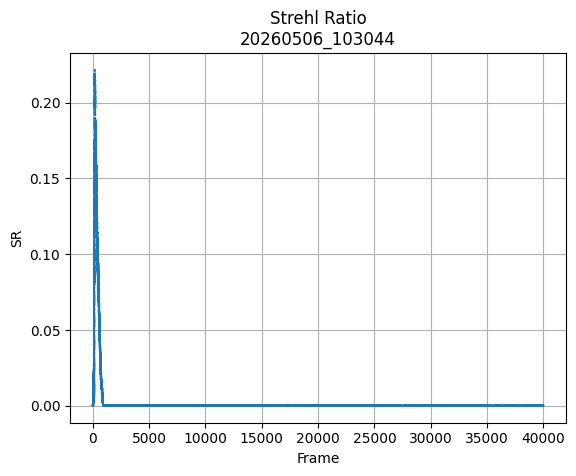

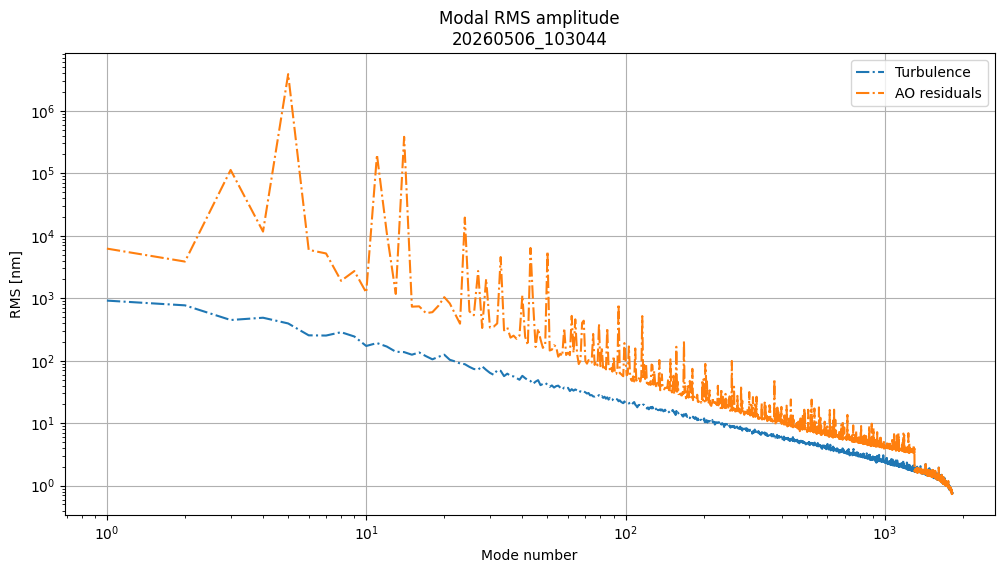

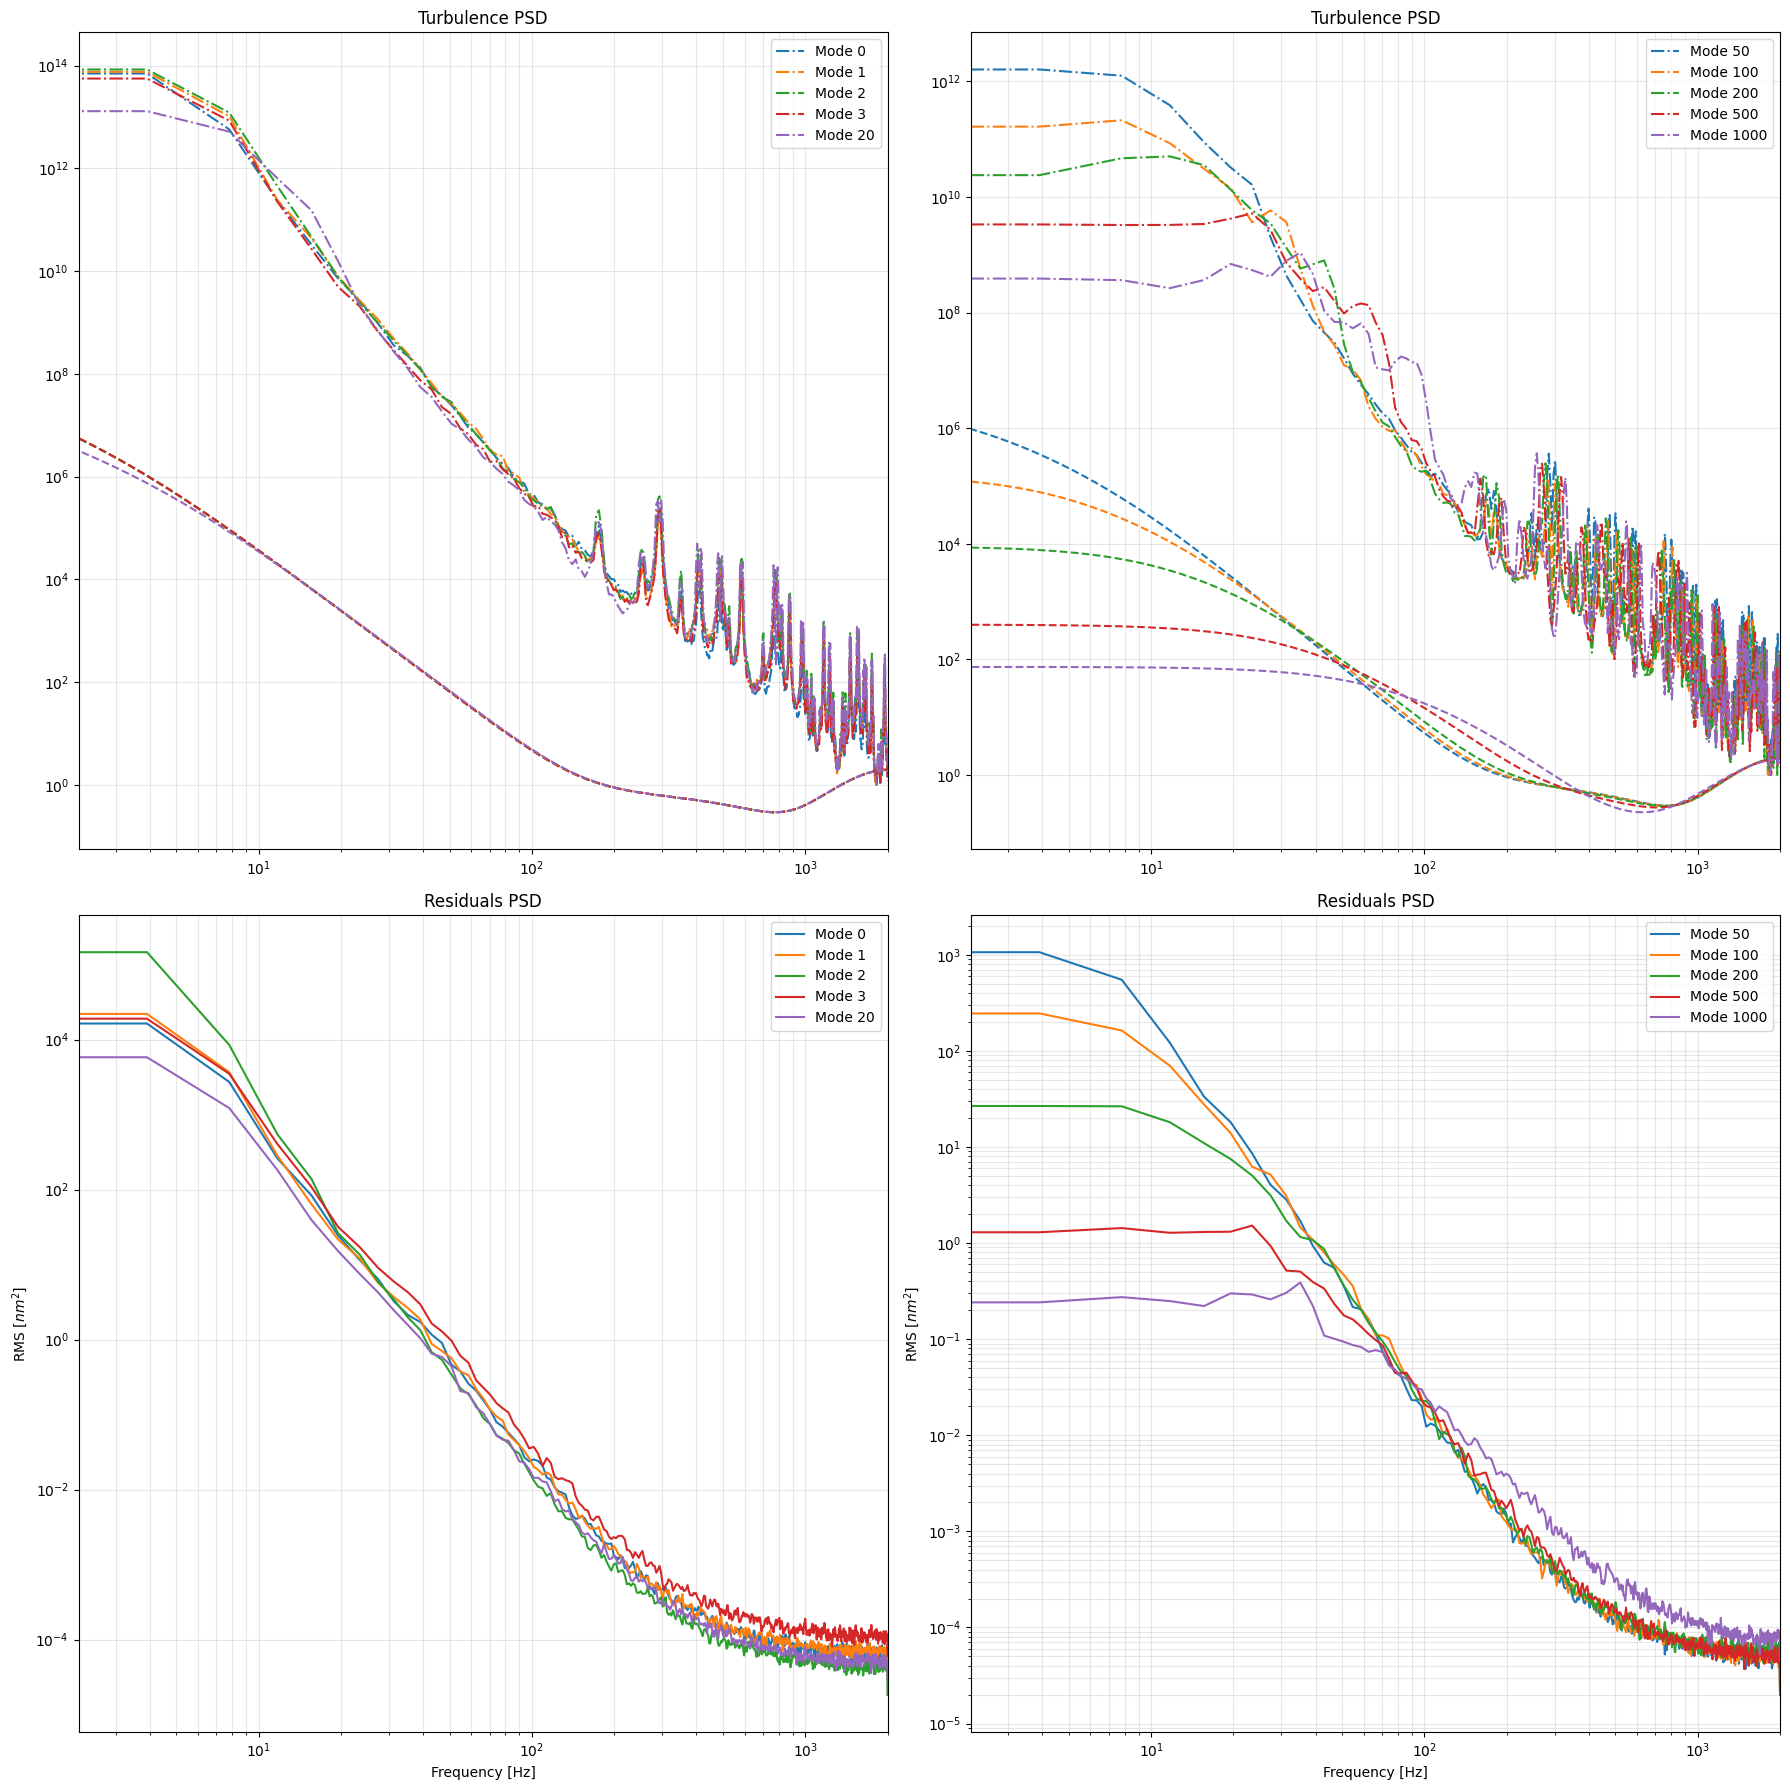

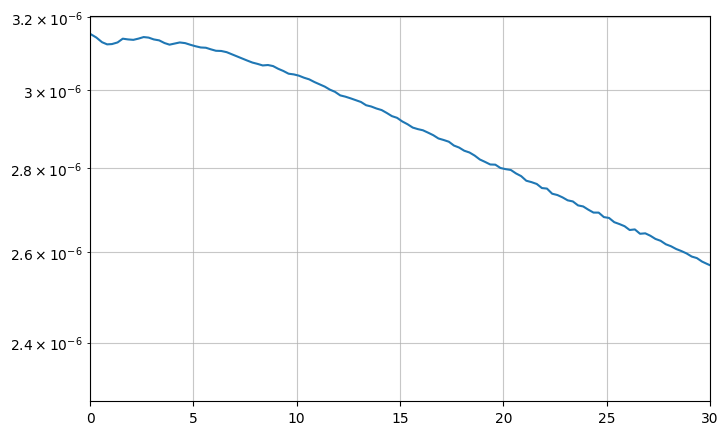

In [4]:
plot_output_data(root_dir=xao_dir,calib_dir=calib_dir)

Using data directory: /raid1/mmenessini/results/Cascading/20260504_131406
key: stage2_modes type: <class 'numpy.ndarray'>
key: sr1 type: <class 'numpy.ndarray'>
key: coro_psf2_profile type: <class 'numpy.ndarray'>
key: dm1_res type: <class 'numpy.ndarray'>
key: psf2_profile type: <class 'numpy.ndarray'>
key: dm2_cmd type: <class 'numpy.ndarray'>
key: stage1_modes type: <class 'numpy.ndarray'>
key: atmo_res type: <class 'numpy.ndarray'>
key: dm1_cmd type: <class 'numpy.ndarray'>
key: coro_psf1_profile type: <class 'numpy.ndarray'>
key: sr2 type: <class 'numpy.ndarray'>
key: ccd1 type: <class 'numpy.ndarray'>
key: dm2_res type: <class 'numpy.ndarray'>
key: ccd2 type: <class 'numpy.ndarray'>
key: psf1_profile type: <class 'numpy.ndarray'>
Average Strehl Ratio after 800 iterations: 0.7269


psf.fits file not found in /raid1/mmenessini/results/Cascading/20260504_131406.
pyr_modes.fits or zwfs_modes.fits file(s) not found in /raid1/mmenessini/results/Cascading/20260504_131406.
coro_psf.fits file not found in /raid1/mmenessini/results/Cascading/20260504_131406.


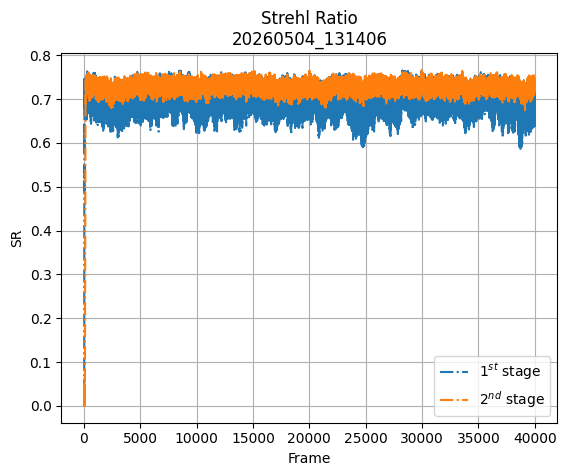

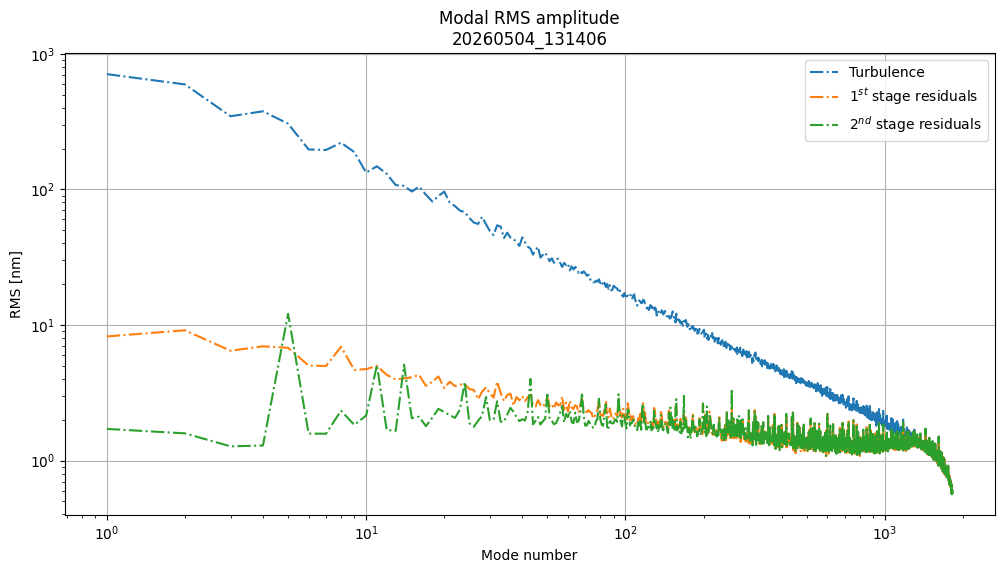

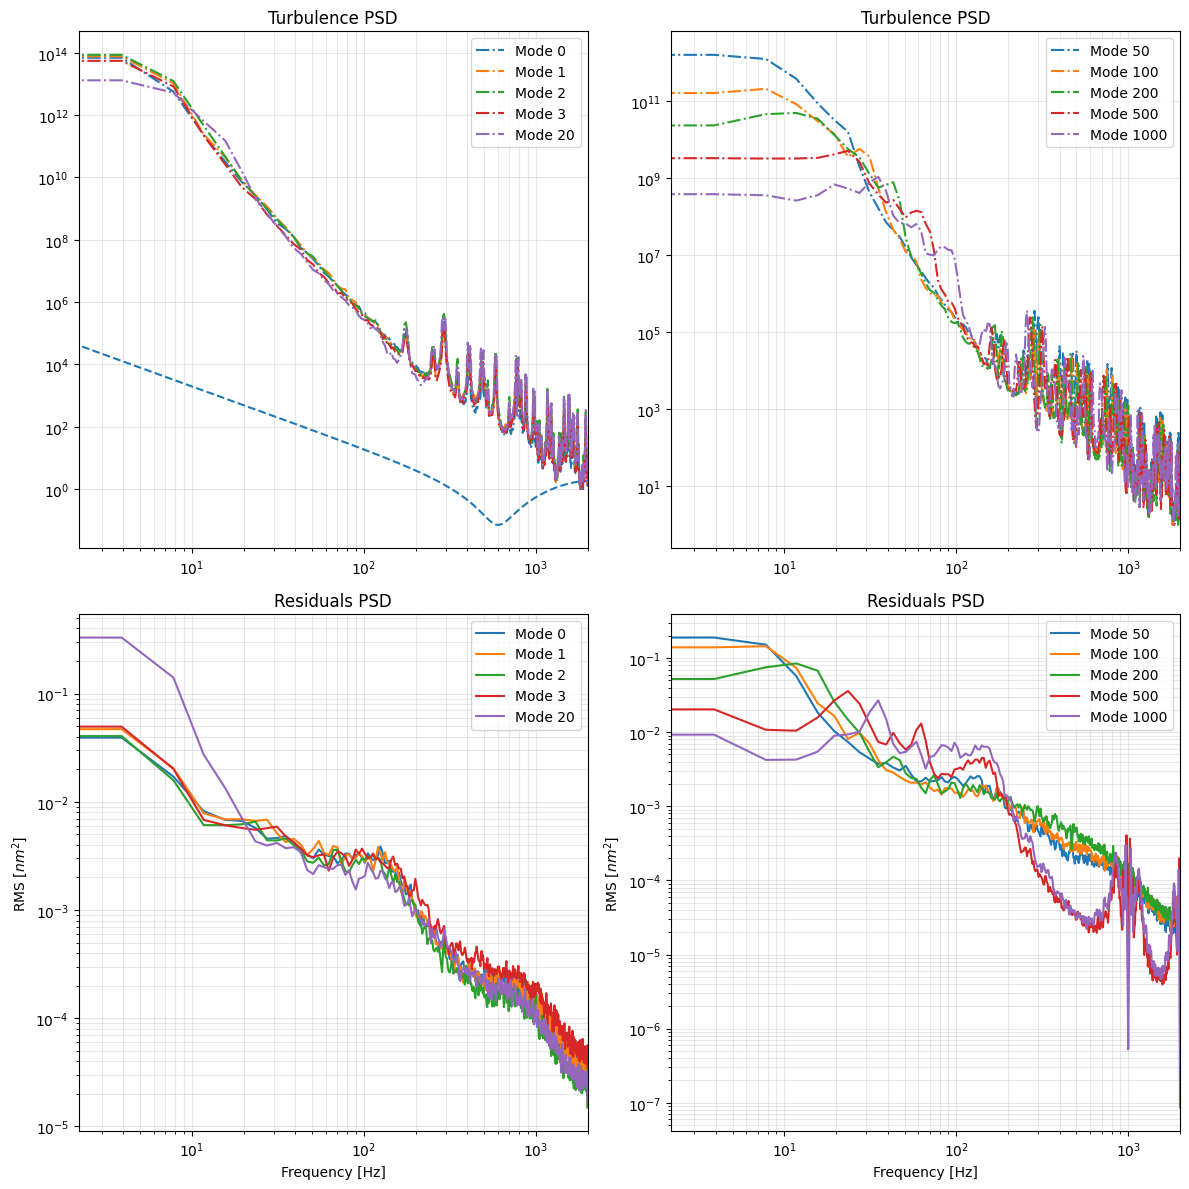

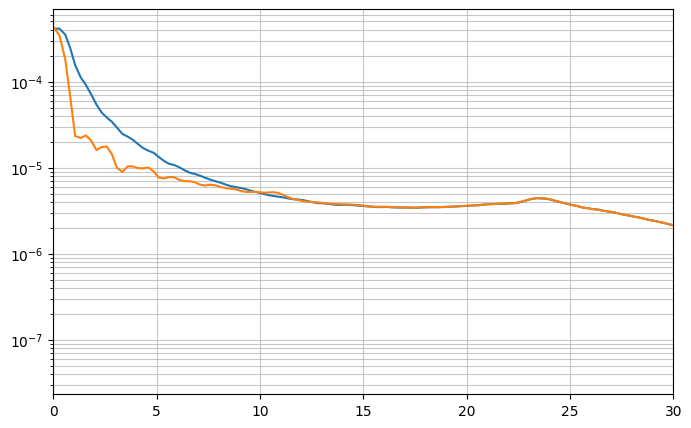

In [5]:
root_dir = '/raid1/mmenessini/results/Cascading'
calib_dir = '/raid1/mmenessini/calibration/XAO'
plot_output_data(root_dir=cascading_dir,calib_dir=calib_dir)

Using data directory: /raid1/mmenessini/results/XAO/20260506_100222
key: sr type: <class 'numpy.ndarray'>
key: dm_cmd type: <class 'numpy.ndarray'>
key: coro_psf_profile type: <class 'numpy.ndarray'>
key: atmo_res type: <class 'numpy.ndarray'>
key: pyr_modes type: <class 'numpy.ndarray'>
key: dm_res type: <class 'numpy.ndarray'>
key: psf_profile type: <class 'numpy.ndarray'>
Using data directory: /raid1/mmenessini/results/XAO/20260506_101833
key: sr type: <class 'numpy.ndarray'>
key: dm_cmd type: <class 'numpy.ndarray'>
key: coro_psf_profile type: <class 'numpy.ndarray'>
key: atmo_res type: <class 'numpy.ndarray'>
key: pyr_modes type: <class 'numpy.ndarray'>
key: dm_res type: <class 'numpy.ndarray'>
key: psf_profile type: <class 'numpy.ndarray'>
Using data directory: /raid1/mmenessini/results/XAO/20260506_103044
key: sr type: <class 'numpy.ndarray'>
key: dm_cmd type: <class 'numpy.ndarray'>
key: coro_psf_profile type: <class 'numpy.ndarray'>
key: atmo_res type: <class 'numpy.ndarray'>


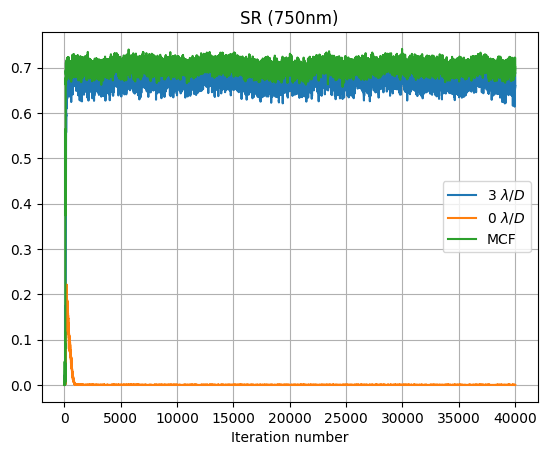

In [6]:
data_mcf = get_sim_data(xao_dir,tn='20260506_100222')
data_pyr3 = get_sim_data(xao_dir,tn='20260506_101833')
data_pyr0 = get_sim_data(xao_dir,tn='20260506_103044')

sr_mcf = data_mcf['sr']
sr_pyr0 = data_pyr0['sr']
sr_pyr3 = data_pyr3['sr']

plt.figure()
plt.plot(sr_pyr3,label=r'3 $\lambda/D$')
plt.plot(sr_pyr0,label=r'0 $\lambda/D$')
plt.plot(sr_mcf,label=r'MCF')
plt.legend()
plt.xlabel('Iteration number')
plt.title('SR (750nm)')
plt.grid()

In [7]:
data_mcf = get_sim_data(xao_dir,tn='20260503_101953')
data_pyr3 = get_sim_data(xao_dir,tn='20260504_085607')
data_pyr0 = get_sim_data(xao_dir,tn='20260504_084533')

Using data directory: /raid1/mmenessini/results/XAO/20260503_101953
key: sr type: <class 'numpy.ndarray'>
key: dm_cmd type: <class 'numpy.ndarray'>
key: coro_psf_profile type: <class 'numpy.ndarray'>
key: atmo_res type: <class 'numpy.ndarray'>
key: dm_res type: <class 'numpy.ndarray'>
key: psf_profile type: <class 'numpy.ndarray'>
Using data directory: /raid1/mmenessini/results/XAO/20260504_085607
key: sr type: <class 'numpy.ndarray'>
key: dm_cmd type: <class 'numpy.ndarray'>
key: coro_psf_profile type: <class 'numpy.ndarray'>
key: atmo_res type: <class 'numpy.ndarray'>
key: dm_res type: <class 'numpy.ndarray'>
key: psf_profile type: <class 'numpy.ndarray'>
Using data directory: /raid1/mmenessini/results/XAO/20260504_084533
key: sr type: <class 'numpy.ndarray'>
key: dm_cmd type: <class 'numpy.ndarray'>
key: coro_psf_profile type: <class 'numpy.ndarray'>
key: atmo_res type: <class 'numpy.ndarray'>
key: dm_res type: <class 'numpy.ndarray'>
key: psf_profile type: <class 'numpy.ndarray'>


In [8]:
# sr_mcf = data_mcf['sr']
# sr_pyr0 = data_pyr0['sr']
# sr_pyr3 = data_pyr3['sr']

# plt.figure()
# plt.plot(sr_pyr3,label=r'3 $\lambda/D$')
# plt.plot(sr_pyr0,label=r'0 $\lambda/D$')
# plt.plot(sr_mcf,label=r'MCF')
# plt.legend()
# plt.xlabel('Iteration number')
# plt.title('SR (750nm)')
# plt.grid()

In [9]:
data_mcf = get_sim_data(xao_dir,tn='20260503_101953')
data_dCAO = get_sim_data(cascading_dir,tn='20260502_105915')
data_CAO = get_sim_data(cascading_dir,tn='20260502_163546')

Using data directory: /raid1/mmenessini/results/XAO/20260503_101953
key: sr type: <class 'numpy.ndarray'>
key: dm_cmd type: <class 'numpy.ndarray'>
key: coro_psf_profile type: <class 'numpy.ndarray'>
key: atmo_res type: <class 'numpy.ndarray'>
key: dm_res type: <class 'numpy.ndarray'>
key: psf_profile type: <class 'numpy.ndarray'>
Using data directory: /raid1/mmenessini/results/Cascading/20260502_105915
key: stage2_modes type: <class 'numpy.ndarray'>
key: sr1 type: <class 'numpy.ndarray'>
key: coro_psf2_profile type: <class 'numpy.ndarray'>
key: dm1_res type: <class 'numpy.ndarray'>
key: dm2_cmd type: <class 'numpy.ndarray'>
key: stage1_modes type: <class 'numpy.ndarray'>
key: atmo_res type: <class 'numpy.ndarray'>
key: dm1_cmd type: <class 'numpy.ndarray'>
key: coro_psf1_profile type: <class 'numpy.ndarray'>
key: sr2 type: <class 'numpy.ndarray'>
key: ccd1 type: <class 'numpy.ndarray'>
key: dm2_res type: <class 'numpy.ndarray'>
key: ccd2 type: <class 'numpy.ndarray'>
Using data direct

In [10]:
# rad_dist, mcf_profile = data_mcf['psf_profile'][0]
# rad_dist, dCAO1_profile = data_dCAO['psf1_profile'][0]
# rad_dist, dCAO2_profile = data_dCAO['psf2_profile'][0]
# rad_dist, CAO2_profile = data_CAO['psf2_profile'][0]

# plt.figure(figsize=(6,5))
# plt.semilogy(rad_dist,dCAO1_profile,label='single stage')
# plt.semilogy(rad_dist,CAO2_profile,label='CAO')
# plt.semilogy(rad_dist,dCAO2_profile,label='dCAO')
# plt.semilogy(rad_dist,mcf_profile,label='MCF')
# plt.xlim([0,10])
# plt.ylim([1e-5,2])
# plt.grid(which='both',alpha=0.5)
# plt.title('Normalized radial PSF profile')
# plt.legend()

Using data directory: /raid1/mmenessini/results/XAO/20260504_122405
key: sr type: <class 'numpy.ndarray'>
key: dm_cmd type: <class 'numpy.ndarray'>
key: coro_psf_profile type: <class 'numpy.ndarray'>
key: atmo_res type: <class 'numpy.ndarray'>
key: pyr_modes type: <class 'numpy.ndarray'>
key: dm_res type: <class 'numpy.ndarray'>
key: psf_profile type: <class 'numpy.ndarray'>
Using data directory: /raid1/mmenessini/results/Cascading/20260504_131406
key: stage2_modes type: <class 'numpy.ndarray'>
key: sr1 type: <class 'numpy.ndarray'>
key: coro_psf2_profile type: <class 'numpy.ndarray'>
key: dm1_res type: <class 'numpy.ndarray'>
key: psf2_profile type: <class 'numpy.ndarray'>
key: dm2_cmd type: <class 'numpy.ndarray'>
key: stage1_modes type: <class 'numpy.ndarray'>
key: atmo_res type: <class 'numpy.ndarray'>
key: dm1_cmd type: <class 'numpy.ndarray'>
key: coro_psf1_profile type: <class 'numpy.ndarray'>
key: sr2 type: <class 'numpy.ndarray'>
key: ccd1 type: <class 'numpy.ndarray'>
key: dm

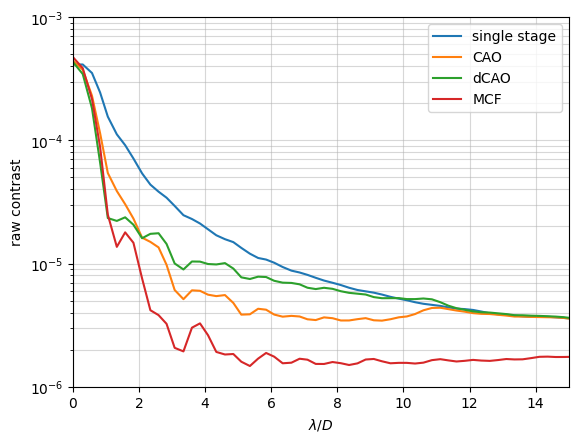

In [11]:
data_mcf = get_sim_data(xao_dir,tn='20260504_122405')
data_dCAO = get_sim_data(cascading_dir,tn='20260504_131406')
data_CAO = get_sim_data(cascading_dir,tn='20260504_124055')

rad_dist, mcf_coro_profile = data_mcf['coro_psf_profile'][0]
rad_dist, CAO1_coro_profile = data_CAO['coro_psf1_profile'][0]
rad_dist, dCAO2_coro_profile = data_dCAO['coro_psf2_profile'][0]
rad_dist, CAO2_coro_profile = data_CAO['coro_psf2_profile'][0]

plt.figure()#figsize=(8,5)
plt.semilogy(rad_dist,CAO1_coro_profile,label='single stage')
plt.semilogy(rad_dist,CAO2_coro_profile,label='CAO')
plt.semilogy(rad_dist,dCAO2_coro_profile,label='dCAO')
plt.semilogy(rad_dist,mcf_coro_profile,label='MCF')
plt.xlim([0,15])
plt.ylim([1e-6,1e-3])
plt.grid(which='both',alpha=0.5)
plt.ylabel('raw contrast')
plt.xlabel(r'$\lambda/D$')
plt.legend()

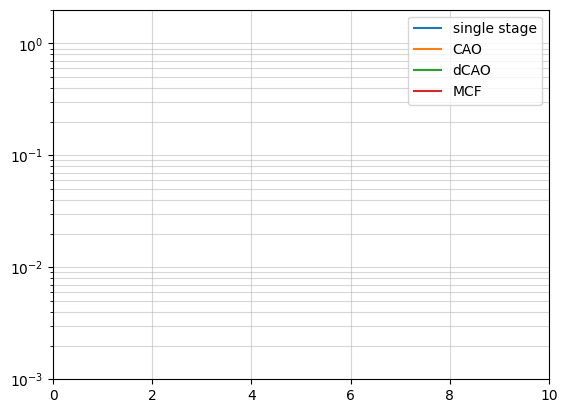

In [12]:
rad_dist, mcf_coro_profile = data_mcf['coro_psf_profile'][0]
rad_dist, dCAO1_coro_profile = data_dCAO['coro_psf1_profile'][0]
rad_dist, dCAO2_coro_profile = data_dCAO['coro_psf2_profile'][0]
rad_dist, CAO2_coro_profile = data_CAO['coro_psf2_profile'][0]

plt.figure()#figsize=(8,5)
plt.semilogy(rad_dist,dCAO1_coro_profile,label='single stage')
plt.semilogy(rad_dist,CAO2_coro_profile,label='CAO')
plt.semilogy(rad_dist,dCAO2_coro_profile,label='dCAO')
plt.semilogy(rad_dist,mcf_coro_profile,label='MCF')
plt.xlim([0,10])
plt.ylim([1e-3,2])
plt.grid(which='both',alpha=0.5)
plt.legend()

In [13]:
ffx,psd_mcf = get_residual_psd(xao_dir,tn='20260503_101953')
# ffc,psd_dCAO1,psd_dCAO2 = get_residual_psd(cascading_dir,tn='20260430_130619')
ffc,psd_CAO1,psd_CAO2 = get_residual_psd(cascading_dir,tn='20260502_111754') #
ffc,psd_dCAO1,psd_dCAO2 = get_residual_psd(cascading_dir,tn='20260502_105915') #,tn='20260502_105915'

Using data directory: /raid1/mmenessini/results/XAO/20260503_101953
key: sr type: <class 'numpy.ndarray'>
key: dm_cmd type: <class 'numpy.ndarray'>
key: coro_psf_profile type: <class 'numpy.ndarray'>
key: atmo_res type: <class 'numpy.ndarray'>
key: dm_res type: <class 'numpy.ndarray'>
key: psf_profile type: <class 'numpy.ndarray'>


Using data directory: /raid1/mmenessini/results/Cascading/20260502_111754
key: stage2_modes type: <class 'numpy.ndarray'>
key: sr1 type: <class 'numpy.ndarray'>
key: coro_psf2_profile type: <class 'numpy.ndarray'>
key: dm1_res type: <class 'numpy.ndarray'>
key: dm2_cmd type: <class 'numpy.ndarray'>
key: stage1_modes type: <class 'numpy.ndarray'>
key: atmo_res type: <class 'numpy.ndarray'>
key: dm1_cmd type: <class 'numpy.ndarray'>
key: coro_psf1_profile type: <class 'numpy.ndarray'>
key: sr2 type: <class 'numpy.ndarray'>
key: ccd1 type: <class 'numpy.ndarray'>
key: dm2_res type: <class 'numpy.ndarray'>
key: ccd2 type: <class 'numpy.ndarray'>
Using data directory: /raid1/mmenessini/results/Cascading/20260502_105915
key: stage2_modes type: <class 'numpy.ndarray'>
key: sr1 type: <class 'numpy.ndarray'>
key: coro_psf2_profile type: <class 'numpy.ndarray'>
key: dm1_res type: <class 'numpy.ndarray'>
key: dm2_cmd type: <class 'numpy.ndarray'>
key: stage1_modes type: <class 'numpy.ndarray'>
ke

Text(0.5, 1.0, 'Residuals PSD\nKL Mode 20')

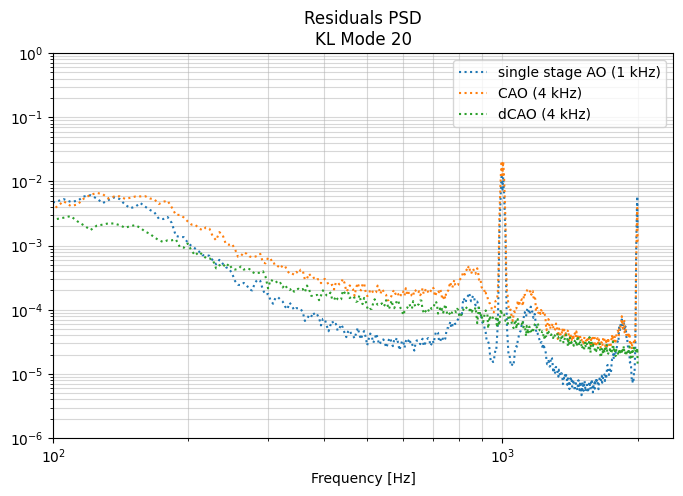

In [14]:
idx = 20
plt.figure(figsize=(8,5))
# plt.loglog(ffx,psd_mcf[idx])
plt.loglog(ffc,psd_dCAO1[idx],':',label='single stage AO (1 kHz)')
plt.loglog(ffc,psd_CAO2[idx],':',label='CAO (4 kHz)')
# plt.loglog(ffc,psd_CAO1[idx],'--',c='C0')
plt.loglog(ffc,psd_dCAO2[idx],':',label='dCAO (4 kHz)')#,c='C3')
plt.legend()
plt.grid(which='both',alpha=0.5)
plt.xlabel('Frequency [Hz]')
# plt.ylabel('Power')
plt.xlim([100,2400])
plt.ylim([1e-6,1])
plt.title(f'Residuals PSD\nKL Mode {idx}')

In [15]:
# root_dir = '/raid1/mmenessini/calibration/XAO'
# check_calibration(root_dir)

In [16]:
# root_dir = '/raid1/mmenessini/calibration/XAO'
# Npix = 160

# compute_and_save_dcao_matrix(root_dir, first_stage_tag='bmc2k_vlt', second_stage_tag='dm468_vlt', N1_modes=1300, N2_modes=300)
# compute_and_save_dcao_matrix(root_dir, first_stage_tag='bmc2k_vlt', second_stage_tag='bmc2k_vlt', N1_modes=1300, N2_modes=300)

# compute_and_save_influence_functions(root_dir,tag='dm241_vlt', pupil_pixels=Npix, n_acts=17,
#                                         geom='alpao', r0=10e-2, obsratio=0.0, pupil_mask_tag='vlt_pupil')

# compute_and_save_influence_functions(root_dir,tag='dm468_vlt', pupil_pixels=Npix, n_acts=24,
#                                         geom='alpao', r0=10e-2, obsratio=0.0, pupil_mask_tag='vlt_pupil')

In [17]:
# gain_dir = '/raid1/mmenessini/results/Cascading'
# plot_gain_optimization(root_dir=gain_dir)

In [18]:
# hdu = fits.open(f'/raid1/mmenessini/calibration/XAO/ifunc/dm468_vlt_ifunc.fits')
# IF = hdu[1].data
# hdu = fits.open(f'/raid1/mmenessini/calibration/XAO/ifunc/dm468_vlt_kl_inv.fits')
# KL = hdu[1].data
# hdu = fits.open(f'/raid1/mmenessini/calibration/XAO/m2c/dm468_vlt_m2c.fits')
# m2c = hdu[1].data


# fname = '/raid1/mmenessini/calibration/XAO/pupilstop/vlt_pupil_160pixels.fits'
# hdu = fits.open(fname)
# pupil_mask = hdu[1].data

# def show_img(flat_img):
#     img = np.zeros(pupil_mask.shape)
#     img[pupil_mask.astype(bool)] = flat_img
#     img = img.reshape(pupil_mask.shape)
#     plt.figure()
#     plt.imshow(img,origin='lower',cmap='RdBu')
#     plt.colorbar()


# print(IF.shape,m2c.shape,KL.shape)

# show_img(IF @ m2c[:,200])
# show_img(KL[200,:])

